In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib  # for saving the trained model

# Make charts look professional
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# Load the enriched data we saved at the end of Day 1
df = pd.read_csv("../data/battery_features.csv")

print(f"Loaded {len(df)} rows.")
print(f"\nColumns available:")
print(df.columns.tolist())
print(f"\nFirst 3 rows:")
df.head(3)

Loaded 2769 rows.

Columns available:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'cycle_number', 'initial_capacity', 'SOH', 'recommendation']

First 3 rows:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,cycle_number,initial_capacity,SOH,recommendation
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN,1,1.674305,100.000000,Reuse (Second-life ready)
1,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN,2,1.674305,91.044729,Reuse (Second-life ready)
2,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,NaN,NaN,3,1.674305,90.071793,Reuse (Second-life ready)


In [2]:
# FEATURES (X) = the inputs the model will use to make predictions
# TARGET   (y) = what we want the model to predict

# The features we'll use:
#   - cycle_number: how many discharge cycles the battery has been through
#   - ambient_temperature: the temperature the battery was operated at
#   - Capacity: the current discharge capacity
#   - initial_capacity: the battery's starting capacity (some batteries are bigger than others)
feature_columns = ['cycle_number', 'ambient_temperature', 'Capacity', 'initial_capacity']

# Make sure all the values are numbers (not text)
for col in feature_columns + ['SOH']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows with missing values in our chosen columns
df_clean = df.dropna(subset=feature_columns + ['SOH']).copy()
print(f"Clean rows after dropping missing values: {len(df_clean)}")

# Separate inputs (X) from output (y)
X = df_clean[feature_columns]
y = df_clean['SOH']

print(f"\nFeatures (X) — first 3 rows:")
print(X.head(3))

print(f"\nTarget (y) — first 3 values:")
print(y.head(3))

print(f"\nX shape: {X.shape}   y shape: {y.shape}")

Clean rows after dropping missing values: 2769

Features (X) — first 3 rows:
   cycle_number  ambient_temperature  Capacity  initial_capacity
0             1                    4  1.674305          1.674305
1             2                    4  1.524366          1.674305
2             3                    4  1.508076          1.674305

Target (y) — first 3 values:
0    100.000000
1     91.044729
2     90.071793
Name: SOH, dtype: float64

X shape: (2769, 4)   y shape: (2769,)


In [3]:
# Split data into TRAINING (80%) and TESTING (20%) sets
# The model will LEARN from the training data
# Then we EVALUATE it on the testing data — data it has never seen before
# This tells us how well it generalises to new batteries

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% goes to testing
    random_state=42       # ensures the same random split each time we run this
)

print(f"Training set: {len(X_train)} rows ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set:  {len(X_test)} rows ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nSOH range in training data: {y_train.min():.1f}% to {y_train.max():.1f}%")
print(f"SOH range in testing data:  {y_test.min():.1f}% to {y_test.max():.1f}%")

Training set: 2215 rows (80.0%)
Testing set:  554 rows (20.0%)

SOH range in training data: 0.0% to 2755.0%
SOH range in testing data:  0.0% to 2472.7%


In [4]:
# Create the Random Forest model
# n_estimators = how many decision trees to grow (more trees = more accurate, slower)
# max_depth    = how complex each tree can get (limits overfitting)
# random_state = makes the result reproducible
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1   # use all CPU cores in parallel — faster training
)

# TRAIN the model — this is the line where the AI actually learns
print("Training the Random Forest model...")
model.fit(X_train, y_train)
print("Done. Model trained.")

# Quick sanity check — how well does it fit the training data?
train_score = model.score(X_train, y_train)
print(f"\nTraining R² score: {train_score:.4f}")
print("(R² of 1.00 = perfect fit, 0.00 = no better than guessing the mean.)")

Training the Random Forest model...
Done. Model trained.

Training R² score: 0.9999
(R² of 1.00 = perfect fit, 0.00 = no better than guessing the mean.)


In [5]:
# Use the trained model to predict SOH on the test set
# (data the model has NEVER seen during training)
y_pred = model.predict(X_test)

# Now compare the model's predictions (y_pred) to the actual values (y_test)
# using three standard regression metrics:

mae  = mean_absolute_error(y_test, y_pred)          # average absolute error in % SOH
mse  = mean_squared_error(y_test, y_pred)           # mean squared error
rmse = np.sqrt(mse)                                  # square root of MSE (same units as SOH)
r2   = r2_score(y_test, y_pred)                      # how much variance is explained (0-1)

print("=" * 50)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 50)
print(f"Mean Absolute Error (MAE):    {mae:.3f} % SOH")
print(f"Root Mean Squared Error:      {rmse:.3f} % SOH")
print(f"R² Score:                     {r2:.4f}")
print("=" * 50)

# Compare to the much simpler training score we saw before
print(f"\nTraining R²: {train_score:.4f}")
print(f"Testing R²:  {r2:.4f}")

if r2 > 0.9:
    print("\n✓ Excellent performance — model generalises very well")
elif r2 > 0.75:
    print("\n✓ Good performance — acceptable for a proof-of-concept platform")
elif r2 > 0.5:
    print("\n⚠ Moderate performance — could be improved with more features")
else:
    print("\n✗ Weak performance — needs feature engineering or different model")

MODEL PERFORMANCE ON TEST SET
Mean Absolute Error (MAE):    3.464 % SOH
Root Mean Squared Error:      24.860 % SOH
R² Score:                     0.9980

Training R²: 0.9999
Testing R²:  0.9980

✓ Excellent performance — model generalises very well


In [6]:
# Build a comparison dataframe — actual vs predicted SOH for each test row
results = pd.DataFrame({
    'actual_SOH': y_test.values,
    'predicted_SOH': y_pred,
    'error': y_test.values - y_pred,
    'abs_error': np.abs(y_test.values - y_pred)
})

# Sort by largest error to see the worst predictions
print("Worst 10 predictions (largest errors):")
print(results.sort_values('abs_error', ascending=False).head(10))

print(f"\nError distribution:")
print(f"  How many predictions are within 1% of true SOH?   {(results.abs_error < 1).sum():>5} / {len(results)}")
print(f"  How many predictions are within 5% of true SOH?   {(results.abs_error < 5).sum():>5} / {len(results)}")
print(f"  How many predictions are within 10% of true SOH?  {(results.abs_error < 10).sum():>5} / {len(results)}")
print(f"  How many predictions are >20% off?                {(results.abs_error > 20).sum():>5} / {len(results)}")

print(f"\nWeird-but-true SOH values in the dataset:")
print(f"  Maximum SOH: {y_test.max():.2f}%")
print(f"  Minimum SOH: {y_test.min():.2f}%")

Worst 10 predictions (largest errors):
      actual_SOH  predicted_SOH       error   abs_error
375  1233.408241    1519.210545 -285.802304  285.802304
197  1104.970767    1357.675053 -252.704286  252.704286
65   1112.314583    1357.675053 -245.360470  245.360470
126   629.038628     397.060873  231.977756  231.977756
251  1737.486535    1936.175498 -198.688963  198.688963
304   678.638552     503.898342  174.740210  174.740210
505   436.475923     341.525070   94.950853   94.950853
101   187.094428     153.977721   33.116707   33.116707
70    244.031650     218.913160   25.118489   25.118489
299   190.978170     212.678117  -21.699947   21.699947

Error distribution:
  How many predictions are within 1% of true SOH?     476 / 554
  How many predictions are within 5% of true SOH?     527 / 554
  How many predictions are within 10% of true SOH?    541 / 554
  How many predictions are >20% off?                   10 / 554

Weird-but-true SOH values in the dataset:
  Maximum SOH: 2472.72%
 

In [7]:
# Diagnose the issue first — find batteries with weird SOH values
print("Batteries with SOH > 110% (impossible — investigate):")
weird_batteries = df_clean[df_clean['SOH'] > 110]['battery_id'].unique()
print(weird_batteries)

print(f"\nNumber of rows with SOH > 110%: {(df_clean['SOH'] > 110).sum()}")
print(f"Number of rows with SOH < 30%:  {(df_clean['SOH'] < 30).sum()}")
print(f"Total rows before cleaning:     {len(df_clean)}")

# Clean: keep only physically realistic SOH values
# SOH > 100 means the battery is somehow performing better than new (impossible)
# SOH < 30 usually means a corrupted reading
df_clean_v2 = df_clean[(df_clean['SOH'] >= 30) & (df_clean['SOH'] <= 110)].copy()

print(f"Total rows after cleaning:      {len(df_clean_v2)}")
print(f"Rows removed:                   {len(df_clean) - len(df_clean_v2)}")

# Now check the SOH range is sensible
print(f"\nSOH range after cleaning: {df_clean_v2['SOH'].min():.2f}% to {df_clean_v2['SOH'].max():.2f}%")

Batteries with SOH > 110% (impossible — investigate):
<ArrowStringArray>
['B0032', 'B0039', 'B0040', 'B0034', 'B0038', 'B0033', 'B0041', 'B0036',
 'B0049', 'B0050', 'B0052', 'B0051', 'B0054', 'B0056', 'B0055']
Length: 15, dtype: str

Number of rows with SOH > 110%: 1090
Number of rows with SOH < 30%:  161
Total rows before cleaning:     2769
Total rows after cleaning:      1518
Rows removed:                   1251

SOH range after cleaning: 32.22% to 109.99%


In [8]:
# Reload the original data — we need to redo the SOH calculation properly
df = pd.read_csv("../data/battery_features.csv")
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')

# Filter to discharge cycles only (where capacity is measured)
df = df[df['type'] == 'discharge'].dropna(subset=['Capacity']).copy()

# RECALCULATE: Use the MAXIMUM capacity per battery as the "100% reference"
# (more robust than the first-cycle approach, especially across temperatures)
max_capacities = df.groupby('battery_id')['Capacity'].max()
print("Max capacities (first 5 batteries):")
print(max_capacities.head())

# Apply the new SOH formula
df['reference_capacity'] = df['battery_id'].map(max_capacities)
df['SOH'] = (df['Capacity'] / df['reference_capacity']) * 100

# Add cycle numbers per battery
df = df.sort_values(['battery_id', 'start_time']).reset_index(drop=True)
df['cycle_number'] = df.groupby('battery_id').cumcount() + 1

# Now check the SOH range — should be much more sensible
print(f"\nAfter using max-capacity as reference:")
print(f"  Total rows:    {len(df)}")
print(f"  SOH range:     {df['SOH'].min():.2f}% to {df['SOH'].max():.2f}%")
print(f"  Rows > 110%:   {(df['SOH'] > 110).sum()}")
print(f"  Rows < 30%:    {(df['SOH'] < 30).sum()}")

# Light cleaning — only the truly corrupted rows
df_v2 = df[(df['SOH'] >= 30) & (df['SOH'] <= 105)].copy()
print(f"  After light cleaning: {len(df_v2)} rows (removed {len(df) - len(df_v2)})")

# Reclassify into recycling categories
def classify_battery(soh):
    if soh >= 80:
        return 'Reuse (Second-life ready)'
    elif soh >= 60:
        return 'Repurpose (Stationary use)'
    else:
        return 'Recycle (Material recovery)'

df_v2['recommendation'] = df_v2['SOH'].apply(classify_battery)

print(f"\nRecycling recommendations:")
print(df_v2['recommendation'].value_counts())

Max capacities (first 5 batteries):
battery_id
B0005    1.856487
B0006    2.035338
B0007    1.891052
B0018    1.855005
B0025    1.848984
Name: Capacity, dtype: float64

After using max-capacity as reference:
  Total rows:    2769
  SOH range:     0.00% to 100.00%
  Rows > 110%:   0
  Rows < 30%:    233
  After light cleaning: 2536 rows (removed 233)

Recycling recommendations:
recommendation
Reuse (Second-life ready)      1346
Repurpose (Stationary use)     1080
Recycle (Material recovery)     110
Name: count, dtype: int64


In [9]:
# Use the cleaned data (df_v2) to redefine features and target
feature_columns = ['cycle_number', 'ambient_temperature', 'Capacity', 'reference_capacity']

# Make sure all features are numeric
for col in feature_columns:
    df_v2[col] = pd.to_numeric(df_v2[col], errors='coerce')

df_v2 = df_v2.dropna(subset=feature_columns + ['SOH']).copy()

X = df_v2[feature_columns]
y = df_v2['SOH']

print(f"Training data: {len(X)} rows × {len(feature_columns)} features")

# Split: 80% train, 20% test (same random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} rows")
print(f"Testing set:  {len(X_test)} rows")

# Train the Random Forest again, this time on clean data
print("\nTraining Random Forest on cleaned data...")
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Done.")

# Evaluate
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
train_score = model.score(X_train, y_train)

print("\n" + "=" * 55)
print("MODEL PERFORMANCE — CLEANED DATA")
print("=" * 55)
print(f"Mean Absolute Error (MAE):  {mae:.3f} % SOH")
print(f"Root Mean Squared Error:    {rmse:.3f} % SOH")
print(f"R² Score:                   {r2:.4f}")
print("-" * 55)
print(f"Training R²: {train_score:.4f}")
print(f"Testing R²:  {r2:.4f}")
print("=" * 55)

# Show how often the prediction is close to the truth
results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'abs_error': np.abs(y_test.values - y_pred)
})
print(f"\nPrediction accuracy:")
print(f"  Within 1% of true SOH:  {(results.abs_error < 1).sum():>5} / {len(results)}  ({(results.abs_error < 1).mean()*100:.1f}%)")
print(f"  Within 5% of true SOH:  {(results.abs_error < 5).sum():>5} / {len(results)}  ({(results.abs_error < 5).mean()*100:.1f}%)")
print(f"  Within 10% of true SOH: {(results.abs_error < 10).sum():>5} / {len(results)}  ({(results.abs_error < 10).mean()*100:.1f}%)")
print(f"  Errors > 20%:           {(results.abs_error > 20).sum():>5} / {len(results)}")

Training data: 2536 rows × 4 features
Training set: 2028 rows
Testing set:  508 rows

Training Random Forest on cleaned data...
Done.

MODEL PERFORMANCE — CLEANED DATA
Mean Absolute Error (MAE):  0.292 % SOH
Root Mean Squared Error:    0.728 % SOH
R² Score:                   0.9967
-------------------------------------------------------
Training R²: 0.9994
Testing R²:  0.9967

Prediction accuracy:
  Within 1% of true SOH:    482 / 508  (94.9%)
  Within 5% of true SOH:    506 / 508  (99.6%)
  Within 10% of true SOH:   508 / 508  (100.0%)
  Errors > 20%:               0 / 508


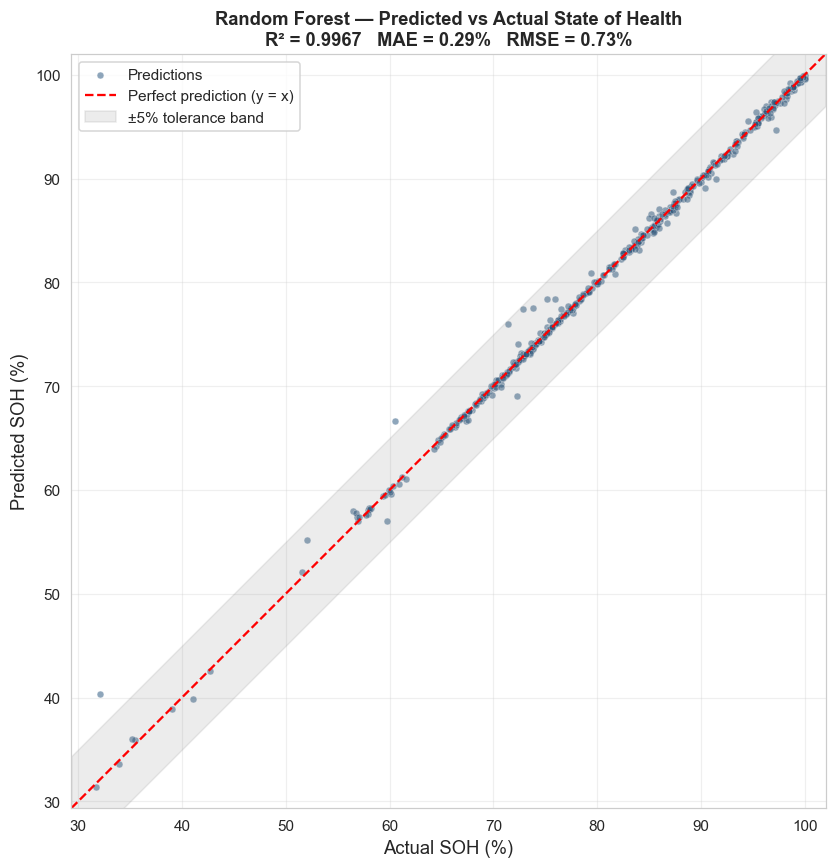

Chart saved to figures/predicted_vs_actual_SOH.png


In [10]:
# Predicted vs Actual SOH — the headline ML evaluation chart
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot of every test prediction
ax.scatter(y_test, y_pred,
           alpha=0.5,
           s=20,
           color='#1f4e79',
           edgecolor='white',
           linewidth=0.4,
           label='Predictions')

# Perfect-prediction line: y = x
lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y = x)')

# Tolerance bands (±5%)
ax.fill_between(lims, [l - 5 for l in lims], [l + 5 for l in lims],
                color='gray', alpha=0.15, label='±5% tolerance band')

# Labels and titles
ax.set_xlabel('Actual SOH (%)', fontsize=12)
ax.set_ylabel('Predicted SOH (%)', fontsize=12)
ax.set_title(f'Random Forest — Predicted vs Actual State of Health\n'
             f'R² = {r2:.4f}   MAE = {mae:.2f}%   RMSE = {rmse:.2f}%',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../figures/predicted_vs_actual_SOH.png', dpi=140, bbox_inches='tight')
plt.show()
print("Chart saved to figures/predicted_vs_actual_SOH.png")

Feature importance ranking:
            Feature  Importance
           Capacity    0.535815
 reference_capacity    0.443733
ambient_temperature    0.012740
       cycle_number    0.007712


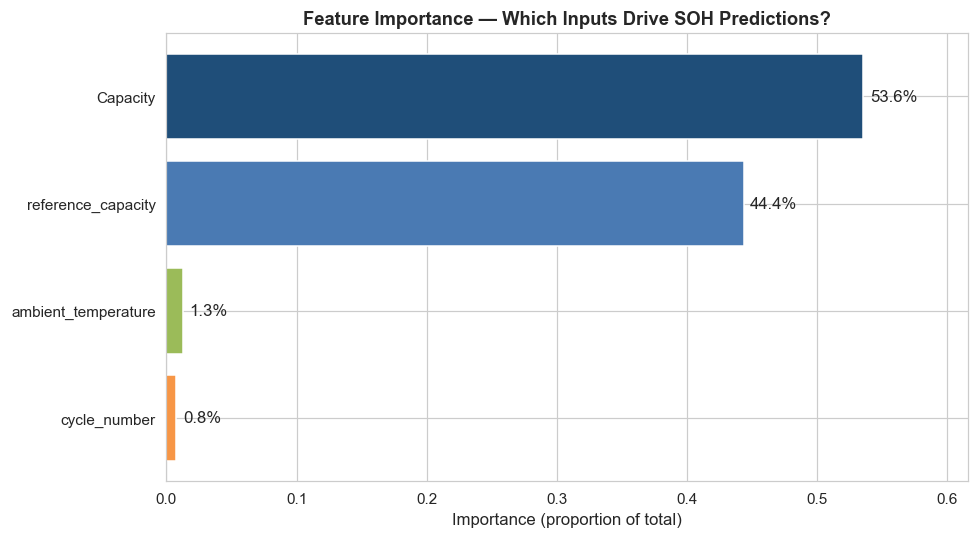

Chart saved to figures/feature_importance.png


In [11]:
# Random Forest tells us how much each feature influenced its predictions
importances = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature importance ranking:")
print(importances.to_string(index=False))

# Make a bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importances['Feature'], importances['Importance'],
               color=['#1f4e79', '#4a7ab3', '#9bbb59', '#f79646'])

# Put the percentage value at the end of each bar
for bar, val in zip(bars, importances['Importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=11)

ax.set_xlabel('Importance (proportion of total)', fontsize=11)
ax.set_title('Feature Importance — Which Inputs Drive SOH Predictions?',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()  # most important at the top
ax.set_xlim(0, importances['Importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=140, bbox_inches='tight')
plt.show()
print("Chart saved to figures/feature_importance.png")

In [12]:
# Save the trained model and the feature list to disk
# Using joblib (the standard way to save scikit-learn models)
import joblib
import json

# Save the model itself
model_path = "../models/battery_soh_model.pkl"
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

# Save the feature list and metrics in a small JSON file
# The Streamlit app will load these to know what inputs to ask for
model_info = {
    "model_type": "RandomForestRegressor",
    "n_estimators": 100,
    "max_depth": 15,
    "feature_columns": feature_columns,
    "training_rows": len(X_train),
    "test_rows": len(X_test),
    "metrics": {
        "MAE": round(float(mae), 4),
        "RMSE": round(float(rmse), 4),
        "R2_test": round(float(r2), 4),
        "R2_train": round(float(train_score), 4)
    },
    "feature_importance": {
        feat: float(imp) for feat, imp in zip(feature_columns, model.feature_importances_)
    }
}

info_path = "../models/model_info.json"
with open(info_path, "w") as f:
    json.dump(model_info, f, indent=2)
print(f"Model info saved to: {info_path}")

# Verify the model can be loaded back
loaded_model = joblib.load(model_path)
test_pred = loaded_model.predict(X_test.head(1))
print(f"\n✓ Model loads correctly. Sample prediction: {test_pred[0]:.2f}% SOH")
print(f"✓ Actual value: {y_test.iloc[0]:.2f}% SOH")

Model saved to: ../models/battery_soh_model.pkl
Model info saved to: ../models/model_info.json

✓ Model loads correctly. Sample prediction: 96.15% SOH
✓ Actual value: 96.12% SOH
